# Day 2 — Exploratory Data Analysis

This notebook explores the cleaned Road Accidents in India dataset.

Main questions:
1. Which States/UTs reported the highest accident counts in 2024?
2. Which States/UTs had the highest accident rate per lakh population?
3. How different are raw-count rankings and normalized-risk rankings?
4. Which States/UTs improved or worsened from 2023 to 2024?
5. What regional patterns appear in the data?

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path 
from IPython.display import display

pd.set_option("display.max_column", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("libraries imported successfully")


libraries imported successfully


In [2]:
processed_dir = Path("../data/processed")

cleaned_path = processed_dir / "accidents_cleaned.csv"
trend_path = processed_dir/ "accidents_trend_long.csv"
total_path = processed_dir/ "national_totals.csv"

accidents = pd.read_csv(cleaned_path)
trend_data = pd.read_csv(trend_path)
national_totals = pd.read_csv(total_path)

print("accidents:" ,accidents.shape)
print("trend_data:" ,trend_data.shape)
print("national_totals:", national_totals.shape)

display(accidents.head())



accidents: (36, 21)
trend_data: (144, 5)
national_totals: (1, 17)


,serial_no,state_ut,accidents_2021,accidents_2022,accidents_2023,accidents_2024,accidents_2024_rank,share_2021_pct,share_2022_pct,share_2023_pct,share_2024_pct,accidents_per_lakh_pop_2021,accidents_per_lakh_pop_2022,accidents_per_lakh_pop_2023,accidents_per_lakh_pop_2024,accidents_per_10k_vehicles_2022,accidents_per_10k_km_roads_2022,vehicle_rate_available,yoy_change_2024_pct,cagr_2021_2024_pct,region
0,1,Andhra Pradesh,21556,21249,19949,19557,9,5.20,4.60,4.20,4.00,40.80,40.10,37.50,36.70,14.20,"1,098.50",True,-1.97,-3.19,South
1,2,Arunachal Pradesh,283,227,287,277,27,0.10,0.00,0.10,0.10,18.50,14.70,18.40,17.60,6.20,42.80,True,-3.48,-0.71,Northeast
2,3,Assam,7411,7023,7421,7848,16,1.80,1.50,1.50,1.60,21.10,19.90,20.80,21.80,15.60,140.10,True,5.75,1.93,Northeast
3,4,Bihar,9553,10801,11014,11610,14,2.30,2.30,2.30,2.40,7.80,8.60,8.70,9.00,9.20,357.50,True,5.41,6.72,East
4,5,Chhattisgarh,12375,13279,13468,14857,11,3.00,2.90,2.80,3.00,42.00,44.50,44.60,48.70,17.00,"1,171.90",True,10.31,6.28,Central


In [3]:
print("Columns:")
print(accidents.columns.tolist())

print("\nMissing values:")
print(accidents.isna().sum()[accidents.isna().sum()>0])

print("\nYears in trend data:")
print(sorted(trend_data["year"].unique()))

print("\nRegions:")
print(accidents["region"].value_counts())


Columns:
['serial_no', 'state_ut', 'accidents_2021', 'accidents_2022', 'accidents_2023', 'accidents_2024', 'accidents_2024_rank', 'share_2021_pct', 'share_2022_pct', 'share_2023_pct', 'share_2024_pct', 'accidents_per_lakh_pop_2021', 'accidents_per_lakh_pop_2022', 'accidents_per_lakh_pop_2023', 'accidents_per_lakh_pop_2024', 'accidents_per_10k_vehicles_2022', 'accidents_per_10k_km_roads_2022', 'vehicle_rate_available', 'yoy_change_2024_pct', 'cagr_2021_2024_pct', 'region']

Missing values:
accidents_per_10k_vehicles_2022    1
dtype: int64

Years in trend data:
[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Regions:
region
Northeast          8
Union Territory    8
North              6
South              5
East               4
West               3
Central            2
Name: count, dtype: int64


## 1. Raw Accident Count vs Population-Normalized Accident Rate 

Raw accident counts can be misleading because larger states may naturally report more accidents due to population size, vehicle volume and road activity.

To get a better risk signal,this section compares:

1. states/UTs ranked by total road accidents in 2024
2. states/UTs ranked by accidents per lakh population in 2024


In [4]:
top_10_raw = (
    accidents[
        [
            "state_ut",
            "region",
            "accidents_2024",
            "accidents_2024_rank",
            "share_2024_pct",
            "accidents_per_lakh_pop_2024"
        ]
    ]
    .sort_values("accidents_2024", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
display(top_10_raw)

,state_ut,region,accidents_2024,accidents_2024_rank,share_2024_pct,accidents_per_lakh_pop_2024
0,Tamil Nadu,South,67526,1,13.80,87.60
1,Madhya Pradesh,Central,56669,2,11.60,64.70
2,Kerala,South,48834,3,10.00,136.00
3,Uttar Pradesh,North,46052,4,9.40,19.30
4,Karnataka,South,43062,5,8.80,63.20
5,Maharashtra,West,36118,6,7.40,28.40
6,Telangana,South,25986,7,5.30,67.90
7,Rajasthan,North,24838,8,5.10,30.30
8,Andhra Pradesh,South,19557,9,4.00,36.70
9,Gujarat,West,15588,10,3.20,21.50


In [5]:
top_10_rate = (
    accidents[
        [
            "state_ut",
            "region",
            "accidents_2024",
            "accidents_2024_rank",
            "share_2024_pct",
            "accidents_per_lakh_pop_2024"
        ]
    ]
    .sort_values("accidents_per_lakh_pop_2024", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
display(top_10_rate)


,state_ut,region,accidents_2024,accidents_2024_rank,share_2024_pct,accidents_per_lakh_pop_2024
0,Goa,West,2682,21,0.50,169.40
1,Kerala,South,48834,3,10.00,136.00
2,Tamil Nadu,South,67526,1,13.80,87.60
3,Ladakh,Union Territory,264,29,0.10,87.40
4,Puducherry,Union Territory,1431,24,0.30,85.00
5,Telangana,South,25986,7,5.30,67.90
6,Madhya Pradesh,Central,56669,2,11.60,64.70
7,Karnataka,South,43062,5,8.80,63.20
8,Chhattisgarh,Central,14857,11,3.00,48.70
9,Jammu and Kashmir,Union Territory,5808,18,1.20,42.40


In [6]:
ranking_comparision = accidents[
    [
        "state_ut",
        'region',
        'accidents_2024',
        "accidents_per_lakh_pop_2024"
    ]
].copy()

ranking_comparision["raw_count_rank"]=(
    ranking_comparision["accidents_2024"]
    .rank(method="dense",ascending=False)
    .astype(int)
)

ranking_comparision["population_rate_rank"] = (
    ranking_comparision["accidents_per_lakh_pop_2024"]
    .rank(method="dense",ascending=False)
    .astype(int)
)

ranking_comparision["rank_difference"] = (
    ranking_comparision["raw_count_rank"]
    - ranking_comparision["population_rate_rank"]
)

ranking_comparision = ranking_comparision.sort_values(
    "rank_difference",
    ascending=False

).reset_index(drop=True)
display(ranking_comparision.head(15))



,state_ut,region,accidents_2024,accidents_per_lakh_pop_2024,raw_count_rank,population_rate_rank,rank_difference
0,Ladakh,Union Territory,264,87.40,29,4,25
1,Andaman and Nicobar Islands,Union Territory,135,33.40,33,12,21
2,Goa,West,2682,169.40,21,1,20
3,Puducherry,Union Territory,1431,85.00,24,5,19
4,Sikkim,Northeast,149,21.40,32,21,11
5,Jammu and Kashmir,Union Territory,5808,42.40,18,10,8
6,Himachal Pradesh,North,2156,28.70,22,15,7
7,Mizoram,Northeast,118,9.40,35,30,5
8,Arunachal Pradesh,Northeast,277,17.60,27,24,3
9,Chandigarh,Union Territory,169,13.60,30,27,3


In [7]:
higher_after_normalization=(
    ranking_comparision
    .sort_values("rank_difference", ascending = False)
    .head(10)
)

lower_after_normalization = (
    ranking_comparision
    .sort_values("rank_difference", ascending = True)
    .head(10)
)

print("States/UTs that look riskier after population mormalization:")
display(higher_after_normalization)

print("States/UTs that look less extreme after population normalization:")
display(lower_after_normalization)

States/UTs that look riskier after population mormalization:


,state_ut,region,accidents_2024,accidents_per_lakh_pop_2024,raw_count_rank,population_rate_rank,rank_difference
0,Ladakh,Union Territory,264,87.40,29,4,25
1,Andaman and Nicobar Islands,Union Territory,135,33.40,33,12,21
2,Goa,West,2682,169.40,21,1,20
3,Puducherry,Union Territory,1431,85.00,24,5,19
4,Sikkim,Northeast,149,21.40,32,21,11
5,Jammu and Kashmir,Union Territory,5808,42.40,18,10,8
6,Himachal Pradesh,North,2156,28.70,22,15,7
7,Mizoram,Northeast,118,9.40,35,30,5
9,Chandigarh,Union Territory,169,13.60,30,27,3
8,Arunachal Pradesh,Northeast,277,17.60,27,24,3


States/UTs that look less extreme after population normalization:


,state_ut,region,accidents_2024,accidents_per_lakh_pop_2024,raw_count_rank,population_rate_rank,rank_difference
35,Uttar Pradesh,North,46052,19.30,4,23,-19
34,Bihar,East,11610,9.00,14,32,-18
33,West Bengal,East,13702,13.80,12,26,-14
32,Gujarat,West,15588,21.50,10,20,-10
31,Maharashtra,West,36118,28.40,6,16,-10
30,Jharkhand,East,5196,13.00,20,28,-8
29,Rajasthan,North,24838,30.30,8,14,-6
28,Madhya Pradesh,Central,56669,64.70,2,7,-5
27,Manipur,Northeast,299,9.20,26,31,-5
25,Punjab,North,6063,19.60,17,22,-5


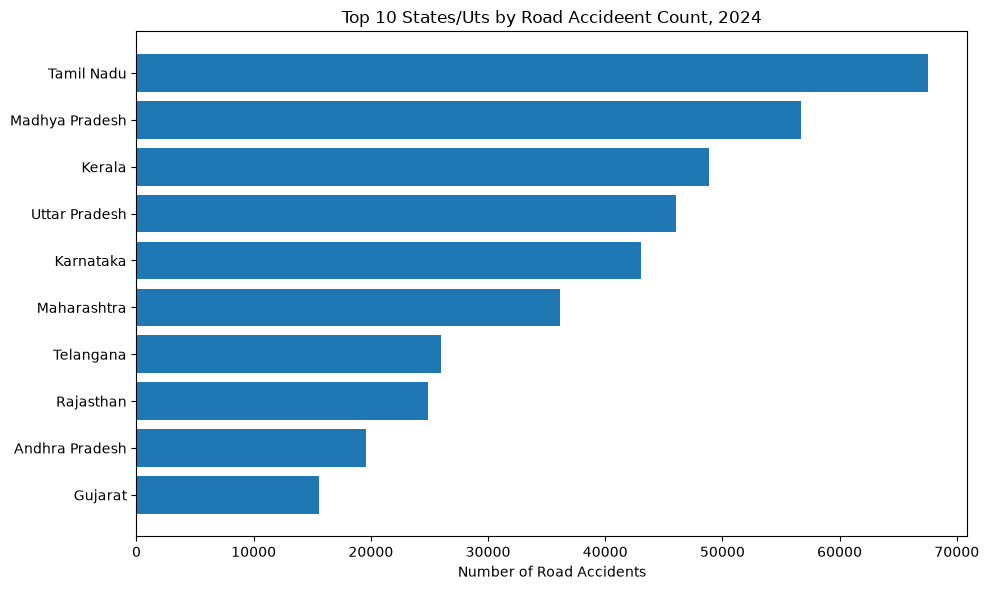

In [8]:
top_10_raw_plot = top_10_raw.sort_values("accidents_2024")

plt.figure(figsize=(10,6))
plt.barh(
    top_10_raw_plot["state_ut"],
    top_10_raw_plot["accidents_2024"]
)

plt.title("Top 10 States/Uts by Road Accideent Count, 2024")
plt.xlabel("Number of Road Accidents")
plt.tight_layout()
plt.show()

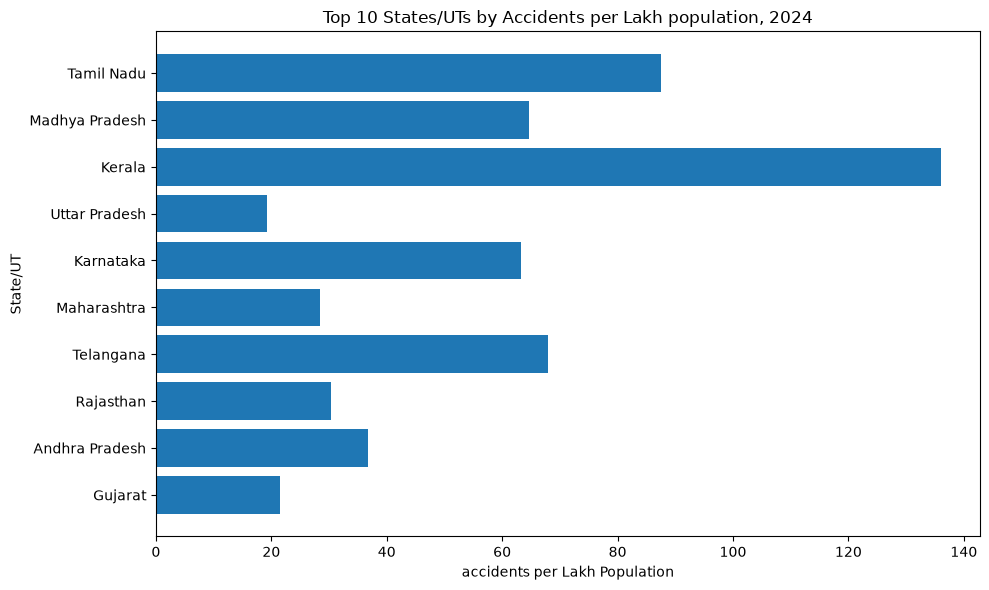

In [9]:
top_10_rate_plot =  top_10_rate.sort_values("accidents_per_lakh_pop_2024")

plt.figure(figsize=(10,6))
plt.barh(
    top_10_raw_plot["state_ut"],
    top_10_raw_plot["accidents_per_lakh_pop_2024"]
)

plt.title("Top 10 States/UTs by Accidents per Lakh population, 2024")
plt.xlabel("accidents per Lakh Population")
plt.ylabel("State/UT")
plt.tight_layout()
plt.show()



### Insight 1 - Raw counts and normalized risk tell different stories

The raw accident-count rankiing is domninated by large State such as Tamil Nadu, Madhya Pradesh, Kerala, uttar pradesh, karnatak and maharashtra.

However, after normalizing accidents per lakh population, smaller States and Union Territories become much more visible. ladakh, andaman and nicobar islands, goa,puducherry, sikkim, jammu and kashmir, Himachal pradesh, mizoram, chandigarh and arunachal pradesh move much higher after normalization

this show that raw accident counts alone should not be used to judge road-safety risk. A state or ut with few total accidents can still have a high accident burden relative to its population.

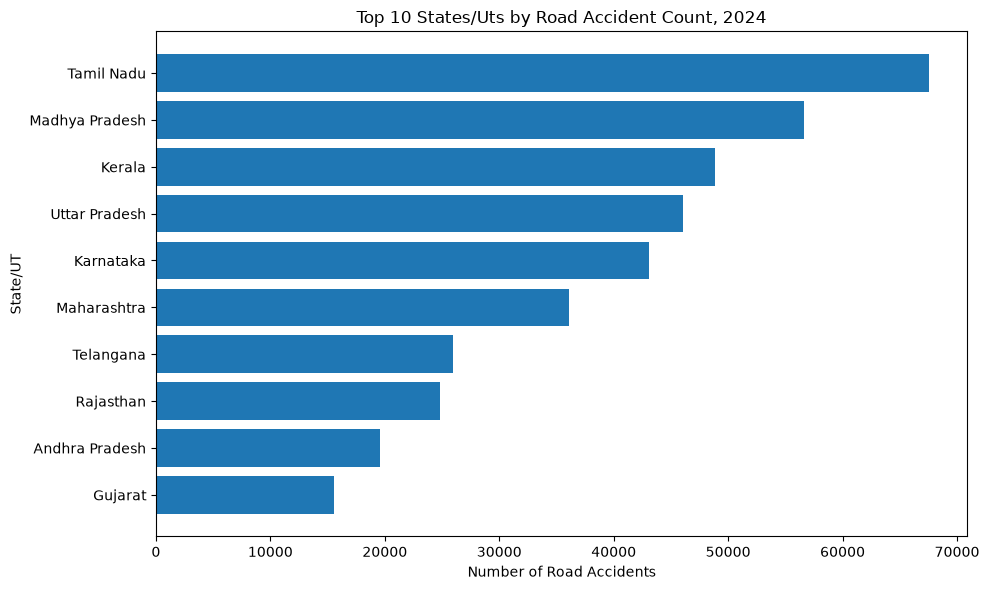

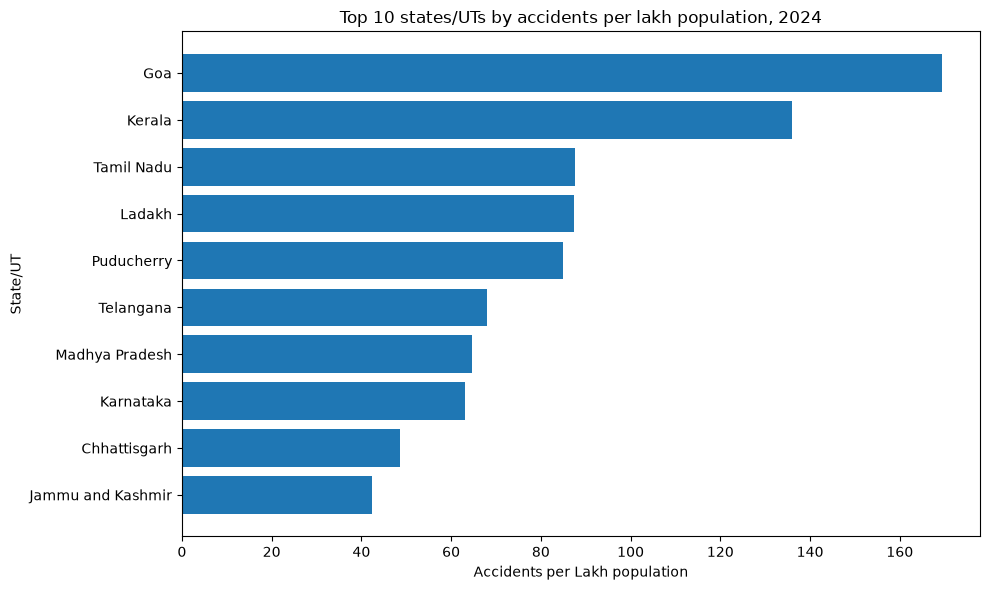

In [10]:
images_dir = Path("../images")
images_dir.mkdir(parents=True,exist_ok=True)

#chart 1
top_10_raw_plot= top_10_raw_plot.sort_values("accidents_2024")

plt.figure(figsize=(10,6))
plt.barh(
    top_10_raw_plot["state_ut"],
    top_10_raw_plot["accidents_2024"]
)

plt.title("Top 10 States/Uts by Road Accident Count, 2024")
plt.xlabel("Number of Road Accidents")
plt.ylabel("State/UT")
plt.tight_layout()
plt.savefig(images_dir/"top_10_raw_accidents_2024.png", dpi=300, bbox_inches="tight")
plt.show()


#chart 2
top_10_rate_plot = top_10_rate.sort_values("accidents_per_lakh_pop_2024")

plt.figure(figsize=(10,6))
plt.barh(
    top_10_rate_plot["state_ut"],
    top_10_rate_plot["accidents_per_lakh_pop_2024"]
)
plt.title("Top 10 states/UTs by accidents per lakh population, 2024")
plt.xlabel("Accidents per Lakh population")
plt.ylabel("State/UT")
plt.tight_layout()
plt.savefig(images_dir/"top_10_accidents_per_lakh_population_2024.png", dpi=300, bbox_inches ='tight')
plt.show()

## 2. Change in Road Accidents from 2023 to 2024

This section identifies States/UTs where road accidents increased or decreased the most between 2023 and 2024.

Two measures are used:

1. Absolute change in number of accidents
2. percentage change from 2023 to 2024

Absolute change shows the size of the increase or decrease, while percentage change shows the relative change compared with the previous year

Calculate absolute change

In [11]:
accidents['absolute_change_2024'] = (
    accidents['accidents_2024'] - accidents['accidents_2023']
)

change_analysis = accidents[
    [
        'state_ut',
        'region',
        'accidents_2023',
        'accidents_2024',
        'absolute_change_2024',
        'yoy_change_2024_pct'
    ]
].copy()

display(change_analysis.head())

,state_ut,region,accidents_2023,accidents_2024,absolute_change_2024,yoy_change_2024_pct
0,Andhra Pradesh,South,19949,19557,-392,-1.97
1,Arunachal Pradesh,Northeast,287,277,-10,-3.48
2,Assam,Northeast,7421,7848,427,5.75
3,Bihar,East,11014,11610,596,5.41
4,Chhattisgarh,Central,13468,14857,1389,10.31


top 10 biggest increases

In [12]:
top_10_increases = (
    change_analysis
    .sort_values("absolute_change_2024", ascending =False)
    .head(10)
    .reset_index(drop=True)
)

display(top_10_increases)

,state_ut,region,accidents_2023,accidents_2024,absolute_change_2024,yoy_change_2024_pct
0,Telangana,South,22903,25986,3083,13.46
1,Uttar Pradesh,North,44534,46052,1518,3.41
2,Chhattisgarh,Central,13468,14857,1389,10.31
3,Madhya Pradesh,Central,55327,56669,1342,2.43
4,Maharashtra,West,35243,36118,875,2.48
5,Kerala,South,48091,48834,743,1.54
6,Bihar,East,11014,11610,596,5.41
7,Assam,Northeast,7421,7848,427,5.75
8,Odisha,East,11992,12375,383,3.19
9,Tamil Nadu,South,67213,67526,313,0.47


Top 10 biggest decreases

In [13]:
top_10_decreases = (
    change_analysis
    .sort_values('absolute_change_2024', ascending=True)
    .head(10)
    .reset_index(drop=True)
)

display(top_10_decreases)

,state_ut,region,accidents_2023,accidents_2024,absolute_change_2024,yoy_change_2024_pct
0,Gujarat,West,16349,15588,-761,-4.65
1,Haryana,North,10463,9806,-657,-6.28
2,Jammu and Kashmir,Union Territory,6298,5808,-490,-7.78
3,Andhra Pradesh,South,19949,19557,-392,-1.97
4,Karnataka,South,43440,43062,-378,-0.87
5,Punjab,North,6269,6063,-206,-3.29
6,Delhi,Union Territory,5834,5657,-177,-3.03
7,Nagaland,Northeast,303,129,-174,-57.43
8,Goa,West,2846,2682,-164,-5.76
9,Jharkhand,East,5315,5196,-119,-2.24


Top 10 percentage increases

In [14]:
top_10_pct_increases = (
    change_analysis
    .sort_values("yoy_change_2024_pct", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_10_pct_increases)

,state_ut,region,accidents_2023,accidents_2024,absolute_change_2024,yoy_change_2024_pct
0,Meghalaya,Northeast,223,269,46,20.63
1,Telangana,South,22903,25986,3083,13.46
2,Mizoram,Northeast,106,118,12,11.32
3,Chhattisgarh,Central,13468,14857,1389,10.31
4,Puducherry,Union Territory,1308,1431,123,9.40
5,Assam,Northeast,7421,7848,427,5.75
6,Bihar,East,11014,11610,596,5.41
7,Uttar Pradesh,North,44534,46052,1518,3.41
8,Uttarakhand,North,1691,1747,56,3.31
9,Odisha,East,11992,12375,383,3.19


Top percentage decreases

In [15]:
top_10_pct_decreases =(
    change_analysis
    .sort_values('yoy_change_2024_pct', ascending=True)
    .head(10)
    .reset_index(drop=True)
)

display(top_10_pct_decreases)

,state_ut,region,accidents_2023,accidents_2024,absolute_change_2024,yoy_change_2024_pct
0,Lakshadweep,Union Territory,1,0,-1,-100.00
1,Nagaland,Northeast,303,129,-174,-57.43
2,Manipur,Northeast,398,299,-99,-24.87
3,Sikkim,Northeast,182,149,-33,-18.13
4,Dadra and Nagar Haveli and Daman and Diu,Union Territory,182,152,-30,-16.48
5,Ladakh,Union Territory,289,264,-25,-8.65
6,Jammu and Kashmir,Union Territory,6298,5808,-490,-7.78
7,Chandigarh,Union Territory,182,169,-13,-7.14
8,Haryana,North,10463,9806,-657,-6.28
9,Goa,West,2846,2682,-164,-5.76


### Insight 2 - Absolute change and percentage change highlight different problems

The absolute-change table shows where the total number of accidents increased the most from 2023 to 2024. Telangana recorded the largest absolute increase, followed by uttar pradesh, chhattisgarh, madhaya pradesh and maharashtra.

The percentage-change table tells a different story. Smaller States/UTs such as meghalaya and mizoram appear much higher becauase their accident counts increased sharply relative to their 2023 base.

On the decrease side, gujarat, haryana, jammu and kashmir, andhra pradesh and karnataka showed the largest absolute reductions in accident coutns. however, in percentage terms, smaller regions such as lakshadweep, magaland, amnipur and sikkim showed the sharpest relative declines.


This comfirms that both absolute change and percentage change are useful:
- Absolute change shows where the national accident burden moved the most.
- percentage change shows where the sutuation changed most sharply relative to the previous year.

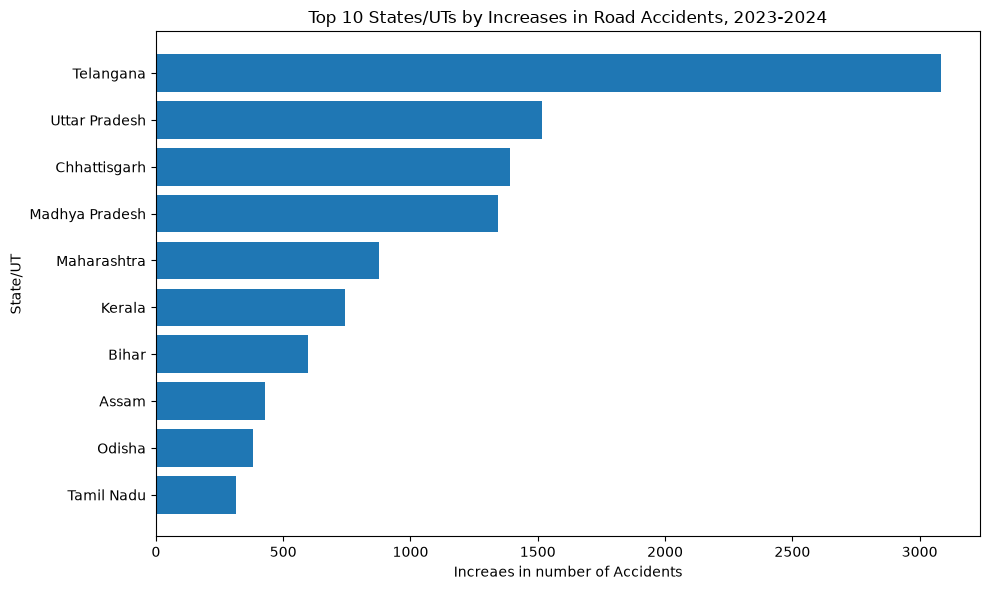

In [16]:
top_10_increases_plot = top_10_increases.sort_values("absolute_change_2024")

plt.figure(figsize=(10,6))
plt.barh(
    top_10_increases_plot['state_ut'],
    top_10_increases_plot['absolute_change_2024']
)

plt.title("Top 10 States/UTs by Increases in Road Accidents, 2023-2024")
plt.xlabel("Increaes in number of Accidents")
plt.ylabel("State/UT")
plt.tight_layout()
plt.show()

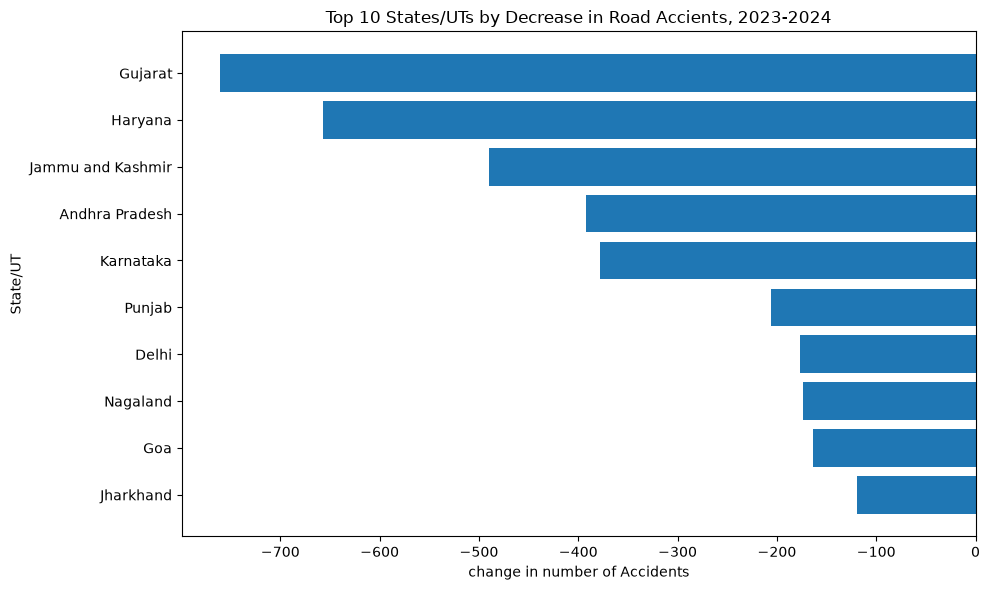

In [17]:
from IPython.core.pylabtools import figsize
top_10_decreases_plot = top_10_decreases.sort_values("absolute_change_2024",ascending=False)

plt.figure(figsize(10,6))
plt.barh(
    top_10_decreases_plot['state_ut'],
    top_10_decreases_plot['absolute_change_2024']
)

plt.title("Top 10 States/UTs by Decrease in Road Accients, 2023-2024")
plt.xlabel("change in number of Accidents")
plt.ylabel("State/UT")
plt.tight_layout()
plt.show()

## 3. Regional Analysis

This section compares road accidents across regions.

The analysis uses:

1. Total accidents in 2024 - to understnad accident volume
2. Average accidents per lakh population - to compare mormalised road accident risk
3. Total absolute change from 2023 to 2024 - to see where accident burden increase or descresed
4. Average YoY percentage change - to compare relative change across regions

Regional summary table

In [18]:
# Ensure absolute change exists
if "absolute_change_2024" not in accidents.columns:
    accidents["absolute_change_2024"] = (
        accidents["accidents_2024"] - accidents["accidents_2023"]
    )

regional_summary = (
    accidents
    .groupby("region")
    .agg(
        state_ut_count=("state_ut", "count"),
        total_accidents_2024=("accidents_2024", "sum"),
        avg_accidents_2024=("accidents_2024", "mean"),
        avg_accidents_per_lakh_pop_2024=("accidents_per_lakh_pop_2024", "mean"),
        median_accidents_per_lakh_pop_2024=("accidents_per_lakh_pop_2024", "median"),
        total_absolute_change_2024=("absolute_change_2024", "sum"),
        avg_yoy_change_2024_pct=("yoy_change_2024_pct", "mean")
    )
    .reset_index()
)

regional_summary = regional_summary.round(2)

display(
    regional_summary.sort_values(
        "total_accidents_2024",
        ascending=False
    )
)

,region,state_ut_count,total_accidents_2024,avg_accidents_2024,avg_accidents_per_lakh_pop_2024,median_accidents_per_lakh_pop_2024,total_absolute_change_2024,avg_yoy_change_2024_pct
4,South,5,204965,"40,993.00",78.28,67.90,3369,2.53
2,North,6,90662,"15,110.33",24.15,24.15,758,-1.10
0,Central,2,71526,"35,763.00",56.70,56.70,2731,6.37
6,West,3,54388,"18,129.33",73.10,28.40,-50,-2.64
1,East,4,42883,"10,720.75",15.60,13.40,767,1.42
5,Union Territory,8,13616,"1,702.00",37.36,29.70,-621,-17.41
3,Northeast,8,9667,"1,208.38",13.36,11.60,170,-8.26


Sorting regions by normalised risk

In [19]:
regional_risk_ranking = (
    regional_summary
    .sort_values(
        "avg_accidents_per_lakh_pop_2024",
        ascending=False
    )
    .reset_index(drop=True)
)

display(regional_risk_ranking)

,region,state_ut_count,total_accidents_2024,avg_accidents_2024,avg_accidents_per_lakh_pop_2024,median_accidents_per_lakh_pop_2024,total_absolute_change_2024,avg_yoy_change_2024_pct
0,South,5,204965,"40,993.00",78.28,67.90,3369,2.53
1,West,3,54388,"18,129.33",73.10,28.40,-50,-2.64
2,Central,2,71526,"35,763.00",56.70,56.70,2731,6.37
3,Union Territory,8,13616,"1,702.00",37.36,29.70,-621,-17.41
4,North,6,90662,"15,110.33",24.15,24.15,758,-1.10
5,East,4,42883,"10,720.75",15.60,13.40,767,1.42
6,Northeast,8,9667,"1,208.38",13.36,11.60,170,-8.26


Sort regions by 2023–2024 change

In [20]:
regional_change_ranking = (
    regional_summary
    .sort_values(
        "total_absolute_change_2024",
        ascending=False
    )
    .reset_index(drop=True)
)

display(regional_change_ranking)

,region,state_ut_count,total_accidents_2024,avg_accidents_2024,avg_accidents_per_lakh_pop_2024,median_accidents_per_lakh_pop_2024,total_absolute_change_2024,avg_yoy_change_2024_pct
0,South,5,204965,"40,993.00",78.28,67.90,3369,2.53
1,Central,2,71526,"35,763.00",56.70,56.70,2731,6.37
2,East,4,42883,"10,720.75",15.60,13.40,767,1.42
3,North,6,90662,"15,110.33",24.15,24.15,758,-1.10
4,Northeast,8,9667,"1,208.38",13.36,11.60,170,-8.26
5,West,3,54388,"18,129.33",73.10,28.40,-50,-2.64
6,Union Territory,8,13616,"1,702.00",37.36,29.70,-621,-17.41


Total accidents by region


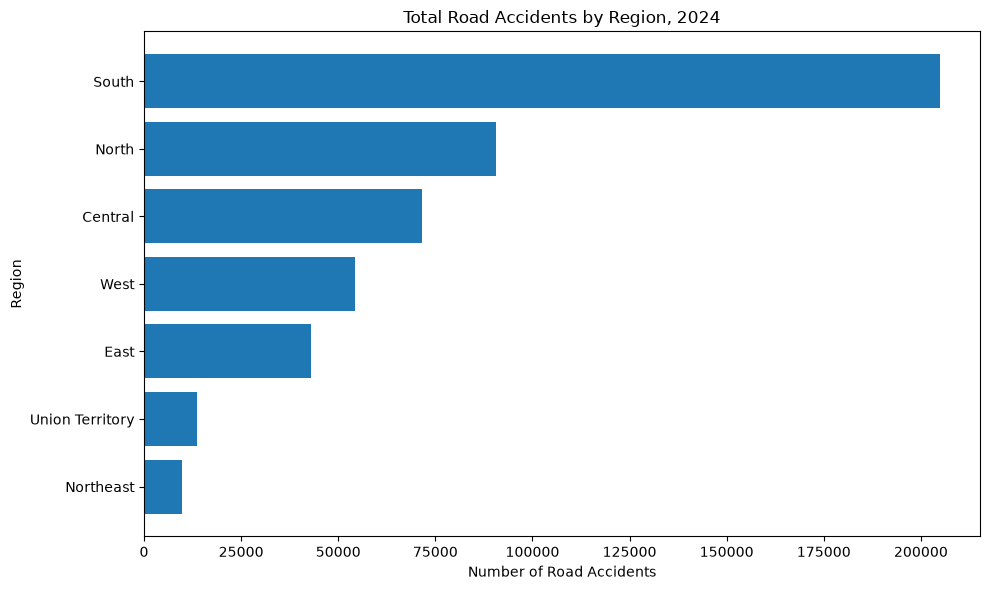

In [21]:
regional_total_plot = regional_summary.sort_values("total_accidents_2024")

plt.figure(figsize=(10, 6))
plt.barh(
    regional_total_plot["region"],
    regional_total_plot["total_accidents_2024"]
)

plt.title("Total Road Accidents by Region, 2024")
plt.xlabel("Number of Road Accidents")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

Average accidents per lakh population by region

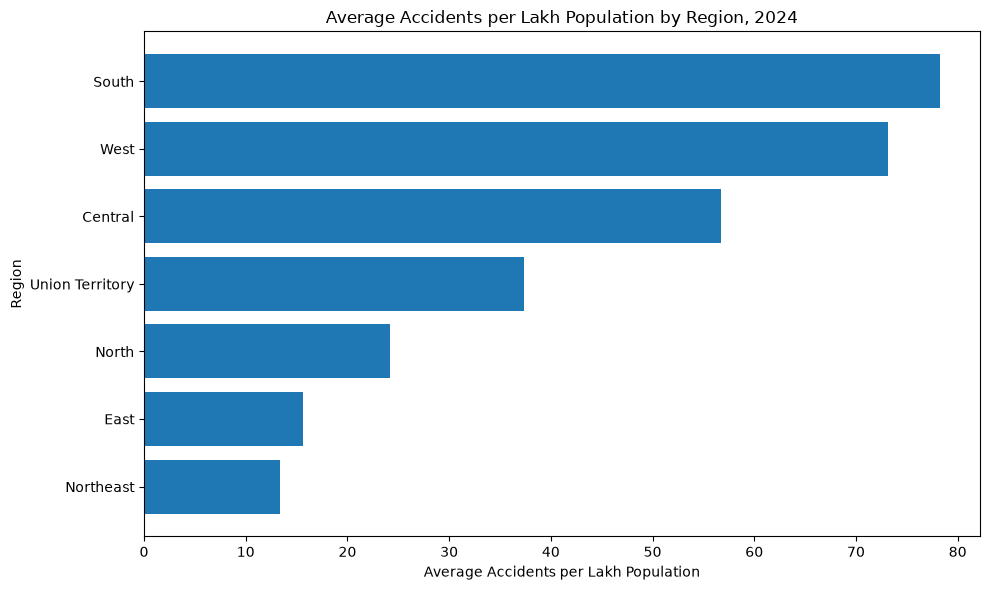

In [22]:
regional_rate_plot = regional_summary.sort_values(
    "avg_accidents_per_lakh_pop_2024"
)

plt.figure(figsize=(10, 6))
plt.barh(
    regional_rate_plot["region"],
    regional_rate_plot["avg_accidents_per_lakh_pop_2024"]
)

plt.title("Average Accidents per Lakh Population by Region, 2024")
plt.xlabel("Average Accidents per Lakh Population")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

Regional change from 2023 to 2024

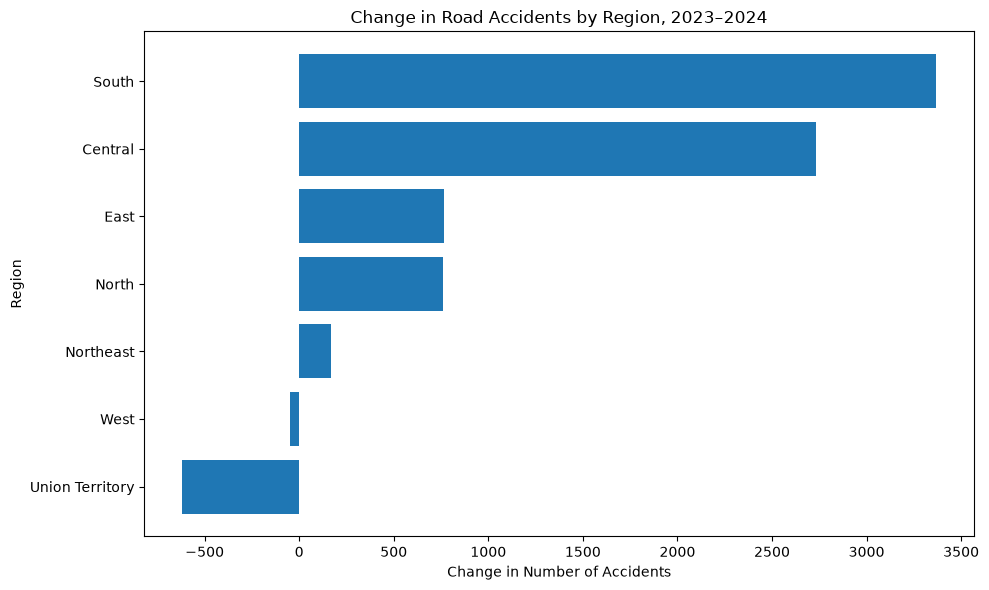

In [23]:
regional_change_plot = regional_summary.sort_values(
    "total_absolute_change_2024"
)

plt.figure(figsize=(10, 6))
plt.barh(
    regional_change_plot["region"],
    regional_change_plot["total_absolute_change_2024"]
)

plt.title("Change in Road Accidents by Region, 2023–2024")
plt.xlabel("Change in Number of Accidents")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

Regional charts

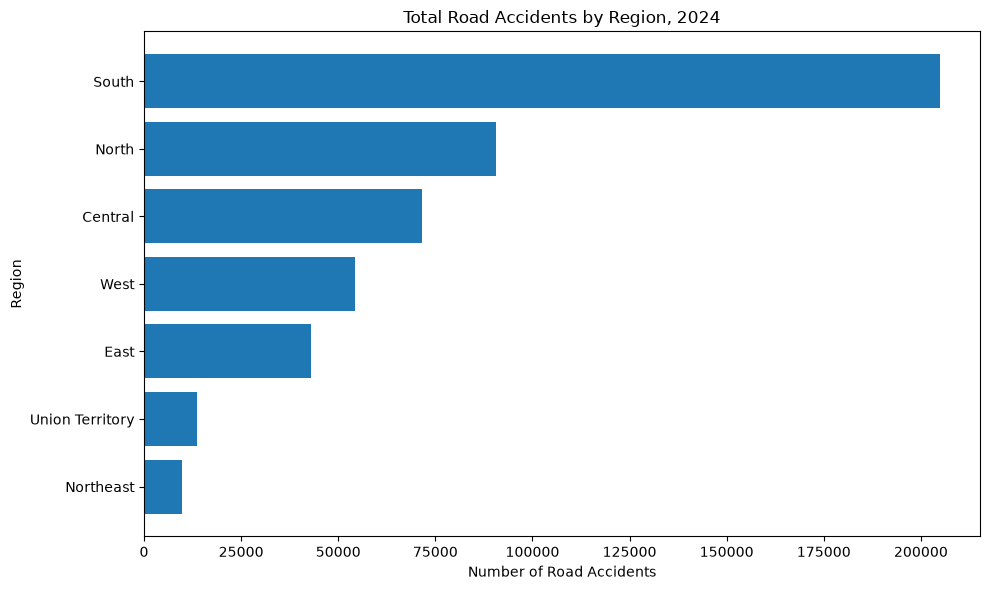

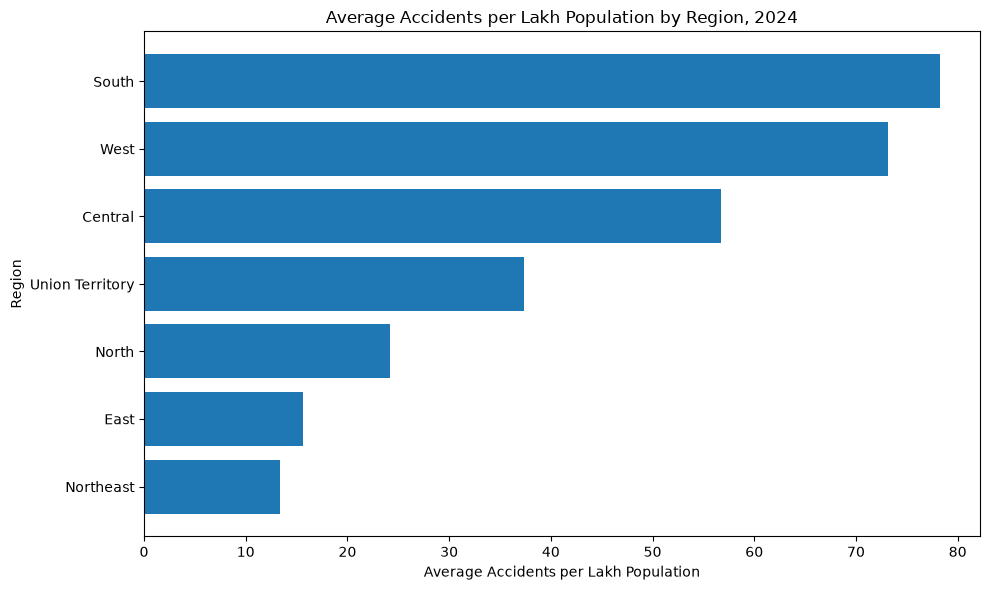

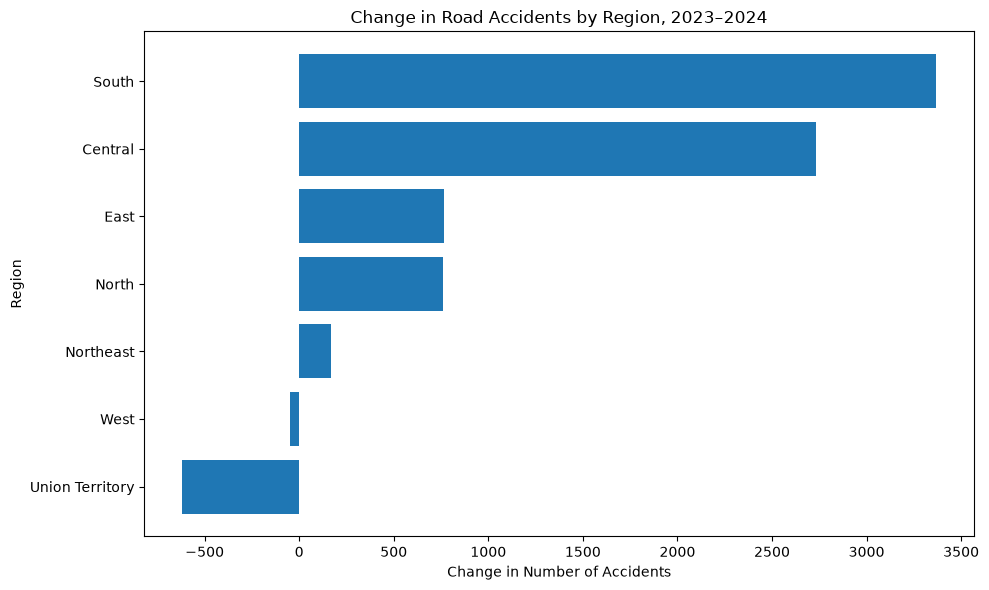

In [24]:
images_dir = Path("../images")
images_dir.mkdir(parents=True, exist_ok=True)

# Total accidents by region
regional_total_plot = regional_summary.sort_values("total_accidents_2024")

plt.figure(figsize=(10, 6))
plt.barh(
    regional_total_plot["region"],
    regional_total_plot["total_accidents_2024"]
)
plt.title("Total Road Accidents by Region, 2024")
plt.xlabel("Number of Road Accidents")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig(
    images_dir / "regional_total_accidents_2024.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Average accidents per lakh population by region
regional_rate_plot = regional_summary.sort_values(
    "avg_accidents_per_lakh_pop_2024"
)

plt.figure(figsize=(10, 6))
plt.barh(
    regional_rate_plot["region"],
    regional_rate_plot["avg_accidents_per_lakh_pop_2024"]
)
plt.title("Average Accidents per Lakh Population by Region, 2024")
plt.xlabel("Average Accidents per Lakh Population")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig(
    images_dir / "regional_avg_accidents_per_lakh_population_2024.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Regional change from 2023 to 2024
regional_change_plot = regional_summary.sort_values(
    "total_absolute_change_2024"
)

plt.figure(figsize=(10, 6))
plt.barh(
    regional_change_plot["region"],
    regional_change_plot["total_absolute_change_2024"]
)
plt.title("Change in Road Accidents by Region, 2023–2024")
plt.xlabel("Change in Number of Accidents")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig(
    images_dir / "regional_change_2023_2024.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Exporting regional summary

In [25]:
regional_summary_path = Path("../data/processed/regional_summary_2024.csv")

regional_summary.to_csv(
    regional_summary_path,
    index=False
)

print("Regional summary exported:")
print(regional_summary_path.resolve())
print("File exists:", regional_summary_path.exists())

Regional summary exported:
/Users/sourabh/Desktop/road-accidents-india-analysis/data/processed/regional_summary_2024.csv
File exists: True


In [26]:
print("Regional summary sorted by total accidents:")
display(
    regional_summary.sort_values(
        "total_accidents_2024",
        ascending=False
    )
)

print("Regional ranking by average accidents per lakh population:")
display(
    regional_summary.sort_values(
        "avg_accidents_per_lakh_pop_2024",
        ascending=False
    )
)

print("Regional ranking by total change from 2023 to 2024:")
display(
    regional_summary.sort_values(
        "total_absolute_change_2024",
        ascending=False
    )
)

Regional summary sorted by total accidents:


,region,state_ut_count,total_accidents_2024,avg_accidents_2024,avg_accidents_per_lakh_pop_2024,median_accidents_per_lakh_pop_2024,total_absolute_change_2024,avg_yoy_change_2024_pct
4,South,5,204965,"40,993.00",78.28,67.90,3369,2.53
2,North,6,90662,"15,110.33",24.15,24.15,758,-1.10
0,Central,2,71526,"35,763.00",56.70,56.70,2731,6.37
6,West,3,54388,"18,129.33",73.10,28.40,-50,-2.64
1,East,4,42883,"10,720.75",15.60,13.40,767,1.42
5,Union Territory,8,13616,"1,702.00",37.36,29.70,-621,-17.41
3,Northeast,8,9667,"1,208.38",13.36,11.60,170,-8.26


Regional ranking by average accidents per lakh population:


,region,state_ut_count,total_accidents_2024,avg_accidents_2024,avg_accidents_per_lakh_pop_2024,median_accidents_per_lakh_pop_2024,total_absolute_change_2024,avg_yoy_change_2024_pct
4,South,5,204965,"40,993.00",78.28,67.90,3369,2.53
6,West,3,54388,"18,129.33",73.10,28.40,-50,-2.64
0,Central,2,71526,"35,763.00",56.70,56.70,2731,6.37
5,Union Territory,8,13616,"1,702.00",37.36,29.70,-621,-17.41
2,North,6,90662,"15,110.33",24.15,24.15,758,-1.10
1,East,4,42883,"10,720.75",15.60,13.40,767,1.42
3,Northeast,8,9667,"1,208.38",13.36,11.60,170,-8.26


Regional ranking by total change from 2023 to 2024:


,region,state_ut_count,total_accidents_2024,avg_accidents_2024,avg_accidents_per_lakh_pop_2024,median_accidents_per_lakh_pop_2024,total_absolute_change_2024,avg_yoy_change_2024_pct
4,South,5,204965,"40,993.00",78.28,67.90,3369,2.53
0,Central,2,71526,"35,763.00",56.70,56.70,2731,6.37
1,East,4,42883,"10,720.75",15.60,13.40,767,1.42
2,North,6,90662,"15,110.33",24.15,24.15,758,-1.10
3,Northeast,8,9667,"1,208.38",13.36,11.60,170,-8.26
6,West,3,54388,"18,129.33",73.10,28.40,-50,-2.64
5,Union Territory,8,13616,"1,702.00",37.36,29.70,-621,-17.41


### Insight 3 — South has the highest accident volume and normalized regional risk

The South region recorded the highest total number of road accidents in 2024, with **204,965 accidents** across five States. It also had the highest average accident rate per lakh population at **78.28**, suggesting that the region stands out not only by raw accident volume but also by normalized accident risk.

The Central region had the second-largest increase in accidents from 2023 to 2024, with a rise of **2,731 accidents**, despite having only two States. This indicates that Madhya Pradesh and Chhattisgarh contributed strongly to the overall increase.

The West region shows an interesting pattern. Its average accidents per lakh population is high at **73.10**, but its median is much lower at **28.40**. This suggests that one or two high-rate States, especially Goa, may be pulling the regional average upward.

Union Territories recorded a decline of **621 accidents** from 2023 to 2024 and had the sharpest average YoY decline at **-17.41%**. However, this should be interpreted carefully because several Union Territories have small accident counts, where even small numerical changes can create large percentage shifts.

Overall, the regional analysis confirms that accident patterns differ depending on whether we look at total volume, normalized risk, or year-over-year change.